The Jawara data is structured as follows:
- Global dataset
- One NETCDF file for each variable
- One NETCDF file for each month (hourly resolution)
- Example: "U1806.nc" for zonal wind for the year 2018 and the month June (06)
- Data: U, V, T (Temperature), Z (geopotential height)
- Data is provided on pressure levels in hPa
- With this script you can load all the data for a defined period, combine the variables in one dataset
    and interpolate it to a regular height grid (default 400m resolution)
- The last paragraph visualizes the original data and the interpolated one for validation.
- Available data is stored in "./2018/raw" 

In [2]:
import os
# from netCDF4 import Dataset
import numpy as np
import pandas as pd
import xarray as xr
import scipy
import datetime
import configparser

import metpy.calc as mpcalc
from metpy.units import units

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import BoundaryNorm, LogNorm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator

from tqdm import tqdm
import plt_helper

plt.style.use('latex_default.mplstyle')

"""Constants"""
# omega = 7.292*10**(-5)
g = 9.80665
Rd = 287.06
cp = 3.5 * Rd
Re = 6371229 # m (Radius of Earth for GRIB2 format - applies to ERA5 on ML)
p0 = 101325

cap=Rd/cp
capi=1/cap
capp=1.-cap # Cv/Cp
cappi=1./capp # Cp/Cv
wexnr=Rd/(cp-Rd) # Rd/Cv
compri=Rd/p0**cap
# th00=tt00*(pr00/pref00)**(-cap)
# rh00=pr00/(rg*tt00)

In [3]:
year = "18"
month = "06"
lat_coral = -53.75
lon_coral = 292.25
folder_raw = "/export/data2/model/jawara/2018/raw"
folder = "/export/data2/model/jawara/2018"

ds_pl = xr.open_dataset(os.path.join(folder_raw, f"Z{year}{month}.nc"))
dsT = xr.open_dataset(os.path.join(folder_raw, f"T{year}{month}.nc"))
dsU = xr.open_dataset(os.path.join(folder_raw, f"U{year}{month}.nc"))
dsV = xr.open_dataset(os.path.join(folder_raw, f"V{year}{month}.nc"))
ds_pl = ds_pl.merge(dsT)
ds_pl = ds_pl.merge(dsU)
ds_pl = ds_pl.merge(dsV)

# ds = ds.sel(latitude=slice(-48,-52), longitudegitudegitude=slice(278,282))

pressure_pa = ds_pl['level'].values * 100.0  # Convert hPa to Pa
pressure_pa = pressure_pa[np.newaxis, :, np.newaxis, np.newaxis]

potential_temperature = mpcalc.potential_temperature(pressure_pa * units.pascal, 
                                                     ds_pl['t'].values * units.kelvin)

ds_pl['th'] = xr.DataArray(potential_temperature.magnitude, 
                    coords=ds_pl['t'].coords, 
                    dims=ds_pl['t'].dims)
# ds_pl = ds_pl.isel(time=slice(0,3))
# ds_pl = ds_pl.sel(time=slice("2018-06-16","2018-06-18"), latitude=slice(-35,-70), longitude=slice(270,310))
ds_pl = ds_pl.sel(latitude=slice(-52,-55), longitude=slice(291,294))
ds_pl

<xarray.Dataset>
Dimensions:    (level: 124, time: 720)
Coordinates:
    longitude  float32 292.5
    latitude   float32 -54.42
  * level      (level) float32 997.5 991.5 983.0 ... 2.839e-06 1.022e-06
  * time       (time) datetime64[ns] 2018-06-01 ... 2018-06-30T23:00:00
Data variables:
    z          (time, level) float32 ...
    t          (time, level) float32 277.3 276.9 276.4 275.5 ... 506.0 644.6 nan
    u          (time, level) float32 ...
    v          (time, level) float32 ...
    th         (time, level) float32 277.5 277.6 277.7 ... 1.784e+05 nan
Attributes:
    history:  2023-03-21 08:01:49 JST koshin> test.rb

In [4]:
zlevels = np.arange(0,140000,400)
new_coords = {
    'time': ds_pl['time'].values,
    'level': zlevels,
    'latitude': ds_pl['latitude'].values,
    'longitude': ds_pl['longitude'].values
}

variables_to_interpolate = ['u','v','p','t','th']
resampled_data = {var: [] for var in variables_to_interpolate}
pressure_profile = ds_pl['level'].values * 100.0

for t in tqdm(range(ds_pl.sizes['time'])):
    for lat in range(ds_pl.sizes['latitude']):
        for lon in range(ds_pl.sizes['longitude']):
            geop_height_profile = ds_pl['z'].isel(time=t, latitude=lat, longitude=lon).values
            for var in variables_to_interpolate:
                if var == "p":
                    var_profile = pressure_profile
                else:
                    var_profile = ds_pl[var].isel(time=t, latitude=lat, longitude=lon).values
                interp_var_func = scipy.interpolate.interp1d(geop_height_profile, var_profile, bounds_error=False, fill_value="extrapolate")
                resampled_profile = interp_var_func(zlevels)
                resampled_data[var].append(resampled_profile)

resampled_vars = {}
for var in variables_to_interpolate:
    resampled_data_array = np.array(resampled_data[var])
    
    # Reshape the data to 4D: (time, altitude, lat, lon)
    reshaped_data = resampled_data_array.reshape(
        (ds_pl.sizes['time'], ds_pl.sizes['latitude'], ds_pl.sizes['longitude'], len(zlevels))
    )
    reshaped_data = reshaped_data.transpose(0, 3, 1, 2)  # Transpose to (time, altitude, lat, lon)

    # Create a new DataArray for this variable
    resampled_vars[var] = xr.DataArray(
        reshaped_data,
        coords=new_coords,
        dims=['time', 'level', 'latitude', 'longitude']
    )
    if var != 'p':
        resampled_vars[var].attrs = ds_pl[var].attrs

ds_resampled = xr.Dataset(resampled_vars)
ds_resampled.to_netcdf(os.path.join(folder,f"jawara_resampled_{year}{month}.nc"))
ds_resampled

  0%|          | 0/720 [00:00<?, ?it/s]

KeyError: 'latitude'

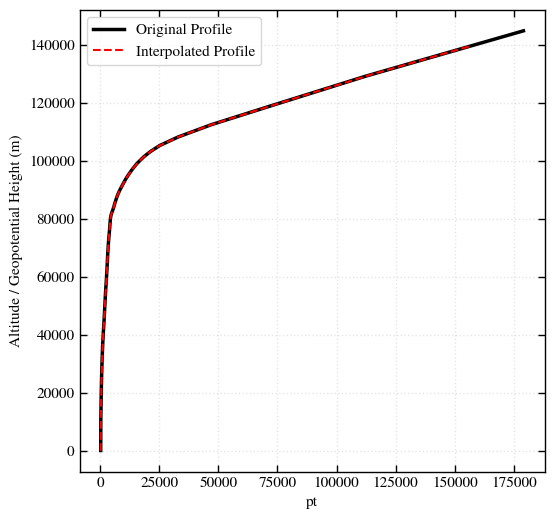

In [13]:
lat = 60
lon = 180 
time = ds_pl['time'][1]
var = "th"

temperature_original = ds_pl[var].sel(time=time, latitude=lat, longitude=lon, method='nearest').values
geopotential_height_original = ds_pl['z'].sel(time=time, latitude=lat, longitude=lon, method='nearest').values

temperature_resampled = ds_resampled[var].sel(time=time, latitude=lat, longitude=lon, method='nearest').values
altitude_levels = ds_resampled['level'].values

# Create a matplotlib plot
plt.figure(figsize=(6,6))

# Plot the original temperature profile with original geopotential height
plt.plot(temperature_original, geopotential_height_original, label='Original Profile', color='black', lw=2.5)

# Plot the resampled temperature profile with uniform altitude levels
plt.plot(temperature_resampled, altitude_levels, label='Interpolated Profile', color='red', ls='--', lw=1.5)

# Add labels and title
plt.xlabel(var)
plt.ylabel('Altitude / Geopotential Height (m)')

# Add a legend
plt.legend()

# Show the plot
plt.grid(True)
plt.show()
